# 03 – Pipeline batch futtatás + Feature extrakció

**Cél:** `run_v14_pipeline` lefuttatása mind a 297 képen, `features_v14.npz` mentése, failure triage CSV exportálása.

**Fázis 0 kapunyitás:** ha `ok == True` < 65% → megáll, hibaelemzés szükséges.

**Modulok:** `src.fretboard`, `src.features`

**Kimenet:**
- `data/features/features_v14.npz` — feature mátrix (N × 56)
- `output/03_pipeline/failure_triage.csv` — sikertelen képek listája okkal

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['GLOG_minloglevel'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from src.config import CFG, PATHS
from src.features import FEATURE_DIM, feature_names, save_features, load_features

print(f'Feature dim: {FEATURE_DIM}')
print(f'Manifest: {PATHS["manifest"]}')

Feature dim: 56
Manifest: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv


In [2]:
# Manifest betöltés
df = pd.read_csv(PATHS['manifest'])
print(f'Képek száma: {len(df)}')
print(df['split'].value_counts().to_string())

Képek száma: 297
split
train    207
test      45
val       45


## 1. Batch pipeline futtatás

Ez a cella fut le legtovább (~5-10 perc 297 képre).

Ha a kernel megszakad: az NPZ mentés az utolsó cellában van, az eredmények addig nem vesznek el.

In [3]:
import builtins
from src.hand_landmark import get_landmarker
from src.fretboard import run_v14_pipeline
from src.features import assemble_feature_vector

# Verbose pipeline print-ek elnémítása
_orig_print = builtins.print
def _silent(*a, **k):
    m = ' '.join(str(x) for x in a)
    if any(t in m for t in ['outer_edges','trapezoid_v9','nut_detect','step7','fret_fit','Hough','klaszter','bővítve']):
        return
    _orig_print(*a, **k)
builtins.print = _silent

landmarker = get_landmarker()
print = _orig_print
print('Landmarker betöltve.')

Landmarker betöltve.


I0000 00:00:1779215172.487333 1071620 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779215172.490711 1071642 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779215172.507777 1071624 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779215172.522433 1071626 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
N = len(df)
class_list = sorted(df['class'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_list)}

X = np.zeros((N, FEATURE_DIM), dtype=np.float32)
y = np.zeros(N, dtype=np.int64)
paths_list = []
splits_list = []
ok_mask = np.zeros(N, dtype=bool)
coverage_arr = np.zeros(N, dtype=np.float32)
failure_rows = []

builtins.print = _silent

for i, (_, row) in enumerate(df.iterrows()):
    r = run_v14_pipeline({'path': row['path'], 'class': row['class']},
                          landmarker=landmarker)
    
    X[i] = assemble_feature_vector(r)
    y[i] = class_to_idx.get(row['class'], 0)
    paths_list.append(str(row['path']))
    splits_list.append(str(row.get('split', 'unknown')))
    ok_mask[i] = bool(r.get('ok', False))
    fit = r.get('fit') or {}
    coverage_arr[i] = float(fit.get('coverage_ratio', 0.0))
    
    if not r.get('ok'):
        failure_rows.append({
            'fname': row.get('fname', str(row['path']).split('/')[-1]),
            'class': row['class'],
            'split': row.get('split', '?'),
            'reason': r.get('invalid_reason', 'unknown'),
        })
    
    del r
    
    if (i + 1) % 50 == 0:
        builtins.print = _orig_print
        n_ok = int(ok_mask[:i+1].sum())
        print(f'  {i+1}/{N}  ok={n_ok} ({n_ok/(i+1)*100:.0f}%)')
        builtins.print = _silent

builtins.print = _orig_print
n_ok = int(ok_mask.sum())
print(f'\nFUTÁS KÉSZ: {n_ok}/{N} = {n_ok/N*100:.1f}% ok')

W0000 00:00:1779215172.889734 1071629 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [extend_amin] a_min 2234.3 → 1650.4 (landmark_min=1690.4, margin=40px)
  [extend_amin] a_min 1405.9 → 740.2 (landmark_min=780.2, margin=40px)
  [extend_amin] a_min 2122.0 → 1124.5 (landmark_min=1164.5, margin=40px)
  [extend_amin] a_min 1861.3 → 1044.4 (landmark_min=1084.4, margin=40px)
  [extend_amin] a_min 2496.5 → 1917.9 (landmark_min=1957.9, margin=40px)
  [extend_amin] a_min 1907.0 → 1633.9 (landmark_min=1673.9, margin=40px)
  [extend_amin] a_min 2365.6 → 1987.0 (landmark_min=2027.0, margin=40px)
  [extend_amin] a_min 3010.5 → 2053.0 (landmark_min=2093.0, margin=40px)
  [extend_amin] a_min 1798.5 → 1076.8 (landmark_min=1116.8, margin=40px)
  [extend_amin] a_min 2856.7 → 1665.7 (landmark_min=1705.7, margin=40px)
  [extend_amin] a_min 3306.8 → 2108.5 (landmark_min=2148.5, margin=40px)
  [extend_amin] a_min 2542.6 → 1722.2 (landmark_min=1762.2, margin=40px)
  [extend_amin] a_min 3132.9 → 1747.5 (landmark_min=1787.5, margin=40px)
  [extend_amin] a_min 1766.3 → 989.0 (landmark_min=10

## 2. Fázis 0 kapunyitás

In [ ]:
ok_rate = n_ok / N
PHASE0_GATE = 0.65

print(f'Fázis 0 ok-ráta: {ok_rate*100:.1f}%  (kapu: {PHASE0_GATE*100:.0f}%)')
if ok_rate >= PHASE0_GATE:
    print('✅ KAPU NYITVA — folytatás a feature elemzéssel')
else:
    print('❌ KAPU ZÁRVA — CFG finomhangolás szükséges, majd újrafuttatás')
    print(f'Hiányzó: {PHASE0_GATE - ok_rate:.1%} ({int((PHASE0_GATE - ok_rate)*N)+1} kép)')

Fázis 0 ok-ráta: 82.5%  (kapu: 65%)
✅ KAPU NYITVA — folytatás a feature elemzéssel


## 3. Failure triage

In [ ]:
fail_df = pd.DataFrame(failure_rows)
if len(fail_df) > 0:
    reason_counts = Counter(fail_df['reason'])
    print('Hibatípusok:')
    for reason, cnt in reason_counts.most_common():
        print(f'  {cnt:3d}  {reason}')
    print(f'\nOsztályonkénti hiba:')
    print(fail_df.groupby('class').size().sort_values(ascending=False).to_string())
else:
    print('Nincs failure!')

Hibatípusok:
   10  trapezoid_sanity: area_frac 0.000 ∉ (0.01, 0.5)
    4  trapezoid_sanity: area_frac 0.005 ∉ (0.01, 0.5)
    3  no_hough_lines
    3  trapezoid_sanity: area_frac 0.007 ∉ (0.01, 0.5)
    2  trapezoid_sanity: area_frac 0.006 ∉ (0.01, 0.5)
    1  trapezoid_sanity: aspect 3.97<4.0
    1  trapezoid_sanity: aspect 3.64<4.0
    1  trapezoid_sanity: aspect 3.66<4.0
    1  trapezoid_sanity: aspect 3.20<4.0
    1  trapezoid_sanity: aspect 2.31<4.0
    1  trapezoid_sanity: aspect 1.26<4.0
    1  trapezoid_sanity: area_frac 0.009 ∉ (0.01, 0.5)
    1  trapezoid_sanity: area_frac 0.001 ∉ (0.01, 0.5)
    1  trapezoid_sanity: aspect 2.66<4.0
    1  trapezoid_sanity: aspect 3.60<4.0
    1  trapezoid_sanity: aspect 3.25<4.0
    1  trapezoid_sanity: area_frac 0.004 ∉ (0.01, 0.5)
    1  trapezoid_sanity: area_frac 0.003 ∉ (0.01, 0.5)
    1  trapezoid_sanity: aspect 3.31<4.0
    1  trapezoid_sanity: aspect 2.77<4.0
    1  trapezoid_sanity: aspect 3.39<4.0
    1  trapezoid_sanity: aspect 1

Coverage (ok képek, n=245):
  min=0.00  median=0.56  mean=0.58  max=1.00
  coverage ≥ 0.40: 189 (77%)
  coverage ≥ 0.50: 160 (65%)


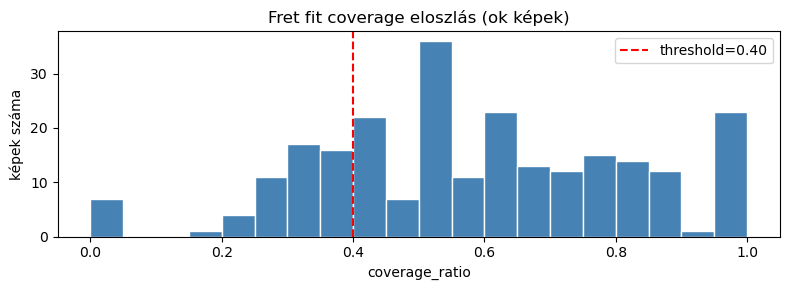

In [ ]:
# Coverage eloszlás az ok képeknél
cov_ok = coverage_arr[ok_mask]
print(f'Coverage (ok képek, n={len(cov_ok)}):')
print(f'  min={cov_ok.min():.2f}  median={np.median(cov_ok):.2f}  mean={cov_ok.mean():.2f}  max={cov_ok.max():.2f}')
print(f'  coverage ≥ 0.40: {(cov_ok>=0.40).sum()} ({(cov_ok>=0.40).mean()*100:.0f}%)')
print(f'  coverage ≥ 0.50: {(cov_ok>=0.50).sum()} ({(cov_ok>=0.50).mean()*100:.0f}%)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cov_ok, bins=20, color='steelblue', edgecolor='white')
ax.axvline(0.40, color='red', linestyle='--', label='threshold=0.40')
ax.set_xlabel('coverage_ratio')
ax.set_ylabel('képek száma')
ax.set_title('Fret fit coverage eloszlás (ok képek)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Feature mátrix mentése

In [ ]:
import numpy as np
from src.features import feature_names, save_features
from src.config import PATHS
from pathlib import Path

batch = {
    'X': X,
    'y': y,
    'classes': class_list,
    'paths': paths_list,
    'splits': splits_list,
    'ok_mask': ok_mask,
    'coverage': coverage_arr,
}

out_path = save_features(batch)
print(f'Mentve: {out_path}')
print(f'Fájlméret: {out_path.stat().st_size / 1024:.1f} KB')
print(f'X shape: {X.shape}  (N={N}, dim={FEATURE_DIM})')
print(f'Classes: {class_list}')

Mentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/features/features_v14.npz
Fájlméret: 50.8 KB
X shape: (297, 56)  (N=297, dim=56)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']


In [ ]:
# Failure triage CSV mentése
output_dir = PATHS['output_dir'] / '03_pipeline'
output_dir.mkdir(parents=True, exist_ok=True)
triage_path = output_dir / 'failure_triage.csv'
fail_df.to_csv(triage_path, index=False)
print(f'Failure triage: {triage_path}  ({len(fail_df)} sor)')

Failure triage: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03_pipeline/failure_triage.csv  (52 sor)


In [ ]:
# Ellenőrző visszaolvasás
loaded = load_features()
assert loaded['X'].shape == (N, FEATURE_DIM), f"Shape mismatch: {loaded['X'].shape}"
assert np.allclose(loaded['X'], X), "X adatok nem egyeznek!"
print('✅ NPZ visszaolvasás OK')
print(f'Feature nevek (első 5): {loaded["feature_names"][:5]}')
print(f'Feature nevek (utolsó 5): {loaded["feature_names"][-5:]}')

✅ NPZ visszaolvasás OK
Feature nevek (első 5): [np.str_('B_wrist_x'), np.str_('B_wrist_y'), np.str_('B_thumb_cmc_x'), np.str_('B_thumb_cmc_y'), np.str_('B_thumb_mcp_x')]
Feature nevek (utolsó 5): [np.str_('H_str_thumb'), np.str_('H_str_index'), np.str_('H_str_middle'), np.str_('H_str_ring'), np.str_('H_str_pinky')]


## 5. Gyors feature összefoglaló split-enként

In [ ]:
splits_arr = np.array(splits_list)
for split in ['train', 'val', 'test']:
    mask = splits_arr == split
    n_split = mask.sum()
    n_ok_split = ok_mask[mask].sum()
    print(f'{split:5s}: {n_split:3d} kép, ok={n_ok_split} ({n_ok_split/n_split*100:.0f}%)')

train: 207 kép, ok=164 (79%)
val  :  45 kép, ok=41 (91%)
test :  45 kép, ok=40 (89%)
